In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
"""Constants"""

mu0 = 4 * np.pi * 1e-7
I = 10
R = 2

num_segments = 500

In [3]:
"""Create the current loop"""

theta = np.linspace(0, 2 * np.pi, num_segments, endpoint=False)

x_loop = R * np.cos(theta)
y_loop = R * np.sin(theta)
z_loop = np.zeros(num_segments)

dtheta = 2 * np.pi / num_segments

dl_x = -R * np.sin(theta) * dtheta
dl_y = R * np.cos(theta) * dtheta
dl_z = np.zeros(num_segments)

In [4]:
"""Observation points along the z-axis"""

z = np.linspace(0, 10, 150)

Bx = np.zeros(len(z))
By = np.zeros(len(z))
Bz = np.zeros(len(z))

In [5]:
"""Compute the magnetic field using the Biot-Savart Law"""

for j in range(len(z)):

    field_x = 0
    field_y = 0
    field_z = 0

    for i in range(num_segments):

        rx = -x_loop[i]
        ry = -y_loop[i]
        rz = z[j]

        r = np.sqrt(rx**2 + ry**2 + rz**2)

        cross_x = dl_y[i] * rz
        cross_y = -dl_x[i] * rz
        cross_z = dl_x[i] * ry - dl_y[i] * rx

        field_x += mu0 * I / (4 * np.pi) * cross_x / r**3
        field_y += mu0 * I / (4 * np.pi) * cross_y / r**3
        field_z += mu0 * I / (4 * np.pi) * cross_z / r**3

    Bx[j] = field_x
    By[j] = field_y
    Bz[j] = field_z

In [6]:
"""Closed-form magnetic field along the z-axis"""

B_closed = (mu0 * I * R**2) / (2 * (R**2 + z**2)**1.5)

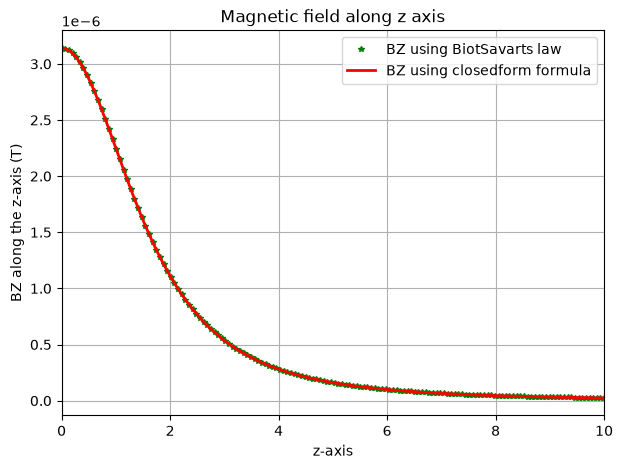

In [7]:
"""Plot both solutions"""

plt.figure(figsize=(7,5))

plt.plot(
    z,
    Bz,
    'g*',
    markersize=4,
    label='BZ using BiotSavarts law'
)

plt.plot(
    z,
    B_closed,
    'r',
    linewidth=2,
    label='BZ using closedform formula'
)

plt.xlabel("z-axis")
plt.ylabel("BZ along the z-axis (T)")
plt.title("Magnetic field along z axis")

plt.xlim(0,10)

plt.grid(True)

plt.legend()

plt.show()

In [8]:
"""Maximum difference between the two methods"""

difference = np.abs(Bz - B_closed)

print("Maximum Difference =", np.max(difference), "Tesla")

Maximum Difference = 3.049318610115481e-20 Tesla
